# Laboratorio de regresión - 4

|                |   |
:----------------|---|
| **Nombre**     | Carlos Enrique Nieves Ochoa |
| **Fecha**      | 14 de septiembre de 2026 |
| **Expediente** | 758210 |

## Modelos penalizados

Hasta ahora la función de costo que usamos para decidir qué tan bueno es nuestro modelo al momento de ajustar es:

$$ \text{RSS} = \sum_{i=1}^n e_i^2 = \sum_{i=1}^n (y_i - \hat{y_i})^2 $$

Dado que los errores obtenidos son una combinación de sesgo y varianza, puede ser que se sesgue un parámetro para minimizar el error. Esto significa que el modelo puede decidir que la salida no sea una combinación de los factores, sino una fuerte predilección sobre uno de los factores solamente. 

E.g. se quiere ajustar un modelo

$$ \hat{z} = \hat{\beta_0} + \hat{\beta_1} x + \hat{\beta_2} y $$

Se ajusta el modelo y se decide que la mejor decisión es $\hat{\beta_1} = 10000$ y $\hat{\beta_2}=50$. Considera limitaciones de problemas reales:
- Quizás los parámetros son ajustes de maquinaria que se deben realizar para conseguir el mejor producto posible, y que $10000$ sea imposible de asignar.
- Quizás los datos actuales están sesgados y sólo hacen parecer que uno de los factores importa más que el otro.

Una de las formas en las que se puede mitigar este problema es penalizando a los parámetros del modelo, cambiando la función de costo:

$$ \text{RSS}_{L2} = \sum_{i=1}^n e_i^2  + \lambda \sum_{j=1}^p \hat{\beta_j}^2 $$

El *L2* significa que se está agregando una penalización de segundo orden. Lo que hace esta penalización es que los factores ahora sólo tendrán permitido crecer si hay una reducción al menos proporcional en el error (sacrificamos sesgo, pero reducimos la varianza).

Asimismo, existe la penalización *L1*

$$ \text{RSS}_{L1} = \sum_{i=1}^n e_i^2  + \lambda \sum_{j=1}^p |\hat{\beta_j}| $$

A las penalizaciones *L2* y *L1* se les conoce también como Ridge y Lasso, respectivamente.

Para realizar una regresión con penalización de Ridge o de Lasso usamos el objeto `Ridge(alpha=?)` o `Lasso(alpha=?)` en lugar de `LinearRegression()` de `sklearn`.

Utiliza el dataset de publicidad (Advertising.csv), utiliza train-test-split de 70/30 y realiza 3 regresiones múltiples:

$$ \text{sales} = \beta_0 + \beta_1 (\text{TV}) + \beta_2 (\text{radio}) + \beta_3 (\text{newspaper}) + \epsilon $$

1. Sin penalización
2. Con penalización L2
3. Con penalización L1

¿Qué puedes observar al ajustar los valores de `alpha`? 

Compara los resultados de los coeficientes utilizando valores diferentes de $\alpha$ y los $R^2$ resultantes.



## Preparación de los datos

In [1]:
# Librerías y datos

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso

df = pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


El archivo contiene la inversión en TV, radio y newspaper, además de las ventas obtenidas. La primera columna sólo identifica cada registro, por lo que no se utiliza como factor.

In [2]:
# Variables del modelo

X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

# Separación de 50 % para entrenamiento y 50 % para prueba

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=15
)

print("Datos de entrenamiento:", X_train.shape[0])
print("Datos de prueba:", X_test.shape[0])

Datos de entrenamiento: 100
Datos de prueba: 100


Se utilizaron 100 observaciones para entrenar los modelos y 100 para probarlos. El valor `random_state=15` permite obtener la misma separación cada vez que se ejecute el archivo.

In [3]:
# Para esta actividad se conservan las unidades originales

X_train.head()

,TV,radio,newspaper
67,139.3,14.5,10.2
111,241.7,38.0,23.2
178,276.7,2.3,23.7
163,163.5,36.8,7.4
109,255.4,26.9,5.5


Cada coeficiente representa el cambio en `sales` por una unidad adicional de inversión en el medio correspondiente.

## 1. Regresión sin penalización

In [4]:
# Modelo sin penalización

lin = LinearRegression()
lin.fit(X_train, y_train)

sin = pd.DataFrame({
    "Modelo": ["Sin penalización"],
    "alpha": [0],
    "B0": [lin.intercept_],
    "TV": [lin.coef_[0]],
    "radio": [lin.coef_[1]],
    "newspaper": [lin.coef_[2]],
    "R2 entrenamiento": [lin.score(X_train, y_train)],
    "R2 prueba": [lin.score(X_test, y_test)]
})

display(sin.round(6))

,Modelo,alpha,B0,TV,radio,newspaper,R2 entrenamiento,R2 prueba
0,Sin penalización,0,2.534016,0.046923,0.190549,0.000942,0.879031,0.910424


El modelo sin penalización obtuvo un R² de 0.8790 en entrenamiento y 0.9104 en prueba. Esto significa que explica aproximadamente el 91.0 % de la variación de las ventas en los datos que no utilizó para entrenarse. Manteniendo los demás factores iguales, una unidad adicional en `TV` se relaciona con un aumento de 0.0469 en `sales`, una unidad de `radio` con 0.1905 y una unidad de `newspaper` con sólo 0.0009.

## 2. Regresión Ridge con penalización L2

In [5]:
# Probar Ridge con diferentes valores de alpha

alphas = [0.01, 0.1, 1, 10, 100, 1000]
filas = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)

    filas.append([
        "Ridge", a, ridge.intercept_,
        ridge.coef_[0], ridge.coef_[1], ridge.coef_[2],
        ridge.score(X_train, y_train),
        ridge.score(X_test, y_test)
    ])

res_ridge = pd.DataFrame(filas, columns=[
    "Modelo", "alpha", "B0", "TV", "radio", "newspaper",
    "R2 entrenamiento", "R2 prueba"
])

display(res_ridge.round(6))

,Modelo,alpha,B0,TV,radio,newspaper,R2 entrenamiento,R2 prueba
0,Ridge,0.01,2.534018,0.046923,0.190549,0.000943,0.879031,0.910424
1,Ridge,0.10,2.534034,0.046923,0.190548,0.000943,0.879031,0.910424
2,Ridge,1.00,2.534200,0.046923,0.190540,0.000945,0.879031,0.910424
3,Ridge,10.00,2.535861,0.046922,0.190452,0.000964,0.879031,0.910432
4,Ridge,100.00,2.552402,0.046912,0.189576,0.001152,0.879024,0.910503
5,Ridge,1000.00,2.711259,0.046815,0.181265,0.002902,0.878354,0.910679


Ridge produce resultados muy parecidos al modelo sin penalización con todos los valores probados. En particular, con `alpha=100` el coeficiente de `radio` es 0.189576 y el R² de prueba es 0.9105. Incluso con `alpha=1000`, el R² queda en 0.9107 y ninguno de los factores se convierte en cero. Esto muestra que Ridge modifica los coeficientes de forma gradual y que, usando las unidades originales, estos valores de `alpha` todavía producen pocos cambios en el modelo.

## 3. Regresión Lasso con penalización L1

In [6]:
# Probar Lasso con diferentes valores de alpha

filas = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train, y_train)

    filas.append([
        "Lasso", a, lasso.intercept_,
        lasso.coef_[0], lasso.coef_[1], lasso.coef_[2],
        lasso.score(X_train, y_train),
        lasso.score(X_test, y_test)
    ])

res_lasso = pd.DataFrame(filas, columns=[
    "Modelo", "alpha", "B0", "TV", "radio", "newspaper",
    "R2 entrenamiento", "R2 prueba"
])

display(res_lasso.round(6))

,Modelo,alpha,B0,TV,radio,newspaper,R2 entrenamiento,R2 prueba
0,Lasso,0.01,2.535695,0.046921,0.190510,0.000929,0.879031,0.910433
1,Lasso,0.10,2.550879,0.046901,0.190147,0.000805,0.879029,0.910515
2,Lasso,1.00,2.693129,0.046716,0.186328,0.000000,0.878821,0.911087
3,Lasso,10.00,3.937218,0.045015,0.144426,0.000000,0.859513,0.899249
4,Lasso,100.00,9.474535,0.030518,0.000000,0.000000,0.501819,0.559469
5,Lasso,1000.00,13.890000,0.000000,0.000000,0.000000,0.000000,-0.002397


Lasso con valores pequeños de `alpha` casi no cambia el modelo. Con `alpha=1`, elimina `newspaper` al llevar su coeficiente a cero y obtiene un R² de prueba de 0.9111, el mejor resultado de la comparación. Con `alpha=10` todavía conserva `TV` y `radio`, pero el R² baja a 0.8992; con `alpha=100` también elimina `radio` y el resultado cae a 0.5595. Finalmente, con `alpha=1000` los tres coeficientes quedan en cero y el R² es negativo, por lo que el modelo funciona peor que utilizar solamente el promedio.

## Comparación de los tres modelos

,Modelo,alpha,B0,TV,radio,newspaper,R2 entrenamiento,R2 prueba
0,Sin penalización,0.00,2.534016,0.046923,0.190549,0.000942,0.879031,0.910424
1,Ridge,0.01,2.534018,0.046923,0.190549,0.000943,0.879031,0.910424
2,Ridge,0.10,2.534034,0.046923,0.190548,0.000943,0.879031,0.910424
3,Ridge,1.00,2.534200,0.046923,0.190540,0.000945,0.879031,0.910424
4,Ridge,10.00,2.535861,0.046922,0.190452,0.000964,0.879031,0.910432
5,Ridge,100.00,2.552402,0.046912,0.189576,0.001152,0.879024,0.910503
6,Ridge,1000.00,2.711259,0.046815,0.181265,0.002902,0.878354,0.910679
7,Lasso,0.01,2.535695,0.046921,0.190510,0.000929,0.879031,0.910433
8,Lasso,0.10,2.550879,0.046901,0.190147,0.000805,0.879029,0.910515
9,Lasso,1.00,2.693129,0.046716,0.186328,0.000000,0.878821,0.911087


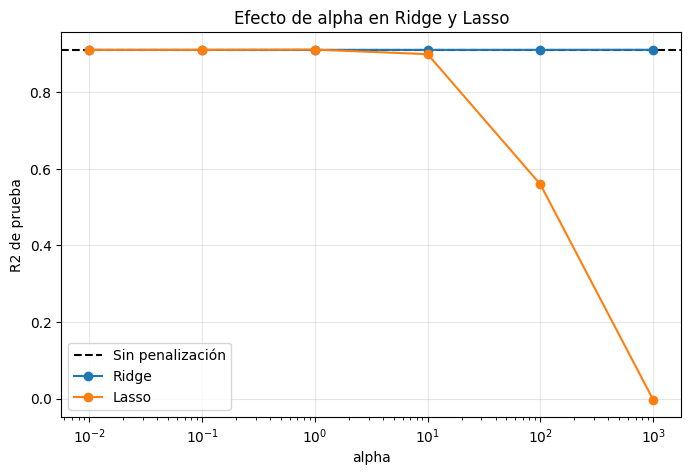

In [7]:
# Tabla con todos los resultados

comparacion = pd.concat([sin, res_ridge, res_lasso], ignore_index=True)
display(comparacion.round(6))

# Comparación del R2 de prueba

plt.figure(figsize=(8, 5))
plt.axhline(
    sin.loc[0, "R2 prueba"], color="black", linestyle="--",
    label="Sin penalización"
)
plt.plot(
    res_ridge["alpha"], res_ridge["R2 prueba"],
    marker="o", label="Ridge"
)
plt.plot(
    res_lasso["alpha"], res_lasso["R2 prueba"],
    marker="o", label="Lasso"
)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("R2 de prueba")
plt.title("Efecto de alpha en Ridge y Lasso")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Al aumentar `alpha`, la penalización se vuelve más fuerte, aunque su efecto no es igual en Ridge y Lasso. Ridge conserva los tres factores y cambia muy poco el R², mientras que Lasso puede llevar algunos coeficientes exactamente a cero. Entre los valores probados, elegiría Lasso con `alpha=1`, ya que obtuvo el mayor R² de prueba, 0.9111, y eliminó `newspaper`. Sin embargo, la mejora frente al modelo sin penalización, cuyo R² fue 0.9104, es muy pequeña. Una penalización demasiado grande termina causando subajuste, como ocurrió con Lasso y `alpha=1000`.